In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns",None)

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/14 days of ML/EDA/nyc-taxi-trip-duration/train/train.csv")
df.head()


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [ ]:
df.tail()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373
1458643,id1209952,1,2016-04-05 14:44:25,2016-04-05 14:47:43,1,-73.979538,40.781750,-73.972809,40.790585,N,198


In [ ]:
df.shape

(1458644, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [ ]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [ ]:
df.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

In [ ]:
df['hour_of_day'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek   # 0=Monday ... 6=Sunday
df['month'] = df['pickup_datetime'].dt.month

In [ ]:
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

df['distance_km'] = haversine(df['pickup_longitude'], df['pickup_latitude'],
                                df['dropoff_longitude'], df['dropoff_latitude'])

In [ ]:
df[['pickup_datetime', 'hour_of_day', 'day_of_week', 'month', 'distance_km', 'trip_duration']].head()

,pickup_datetime,hour_of_day,day_of_week,month,distance_km,trip_duration
0,2016-03-14 17:24:55,17,0,3,1.498521,455
1,2016-06-12 00:43:35,0,6,6,1.805507,663
2,2016-01-19 11:35:24,11,1,1,6.385098,2124
3,2016-04-06 19:32:31,19,2,4,1.485498,429
4,2016-03-26 13:30:55,13,5,3,1.188588,435


In [ ]:
# 0 passengers
print("0 passengers:", (df['passenger_count'] == 0).sum())

# Trip duration  outliers
print("trip_duration < 60 sec:", (df['trip_duration'] < 60).sum())
print("trip_duration > 86400 sec (1 din se zyada):", (df['trip_duration'] > 86400).sum())

# Distance  outliers
print("distance_km == 0:", (df['distance_km'] == 0).sum())
print("distance_km > 100 km:", (df['distance_km'] > 100).sum())

# NYC coordinates outliers
print("pickup lat/long NYC outliers:",
      ((df['pickup_latitude'] < 40) | (df['pickup_latitude'] > 41.5) |
       (df['pickup_longitude'] < -74.5) | (df['pickup_longitude'] > -73)).sum())

0 passengers: 60
trip_duration < 60 sec: 8595
trip_duration > 86400 sec (1 din se zyada): 4
distance_km == 0: 5897
distance_km > 100 km: 19
pickup lat/long NYC outliers: 43


In [ ]:
print("Before:", df.shape)

df = df[df['passenger_count'] > 0]
df = df[(df['trip_duration'] >= 60) & (df['trip_duration'] <= 86400)]
df = df[df['distance_km'] > 0]
df = df[df['distance_km'] <= 100]
df = df[(df['pickup_latitude'] >= 40) & (df['pickup_latitude'] <= 41.5) &
        (df['pickup_longitude'] >= -74.5) & (df['pickup_longitude'] <= -73)]
df = df[(df['dropoff_latitude'] >= 40) & (df['dropoff_latitude'] <= 41.5) &
        (df['dropoff_longitude'] >= -74.5) & (df['dropoff_longitude'] <= -73)]

print("After:", df.shape)

Before: (1458644, 15)
After: (1445757, 15)


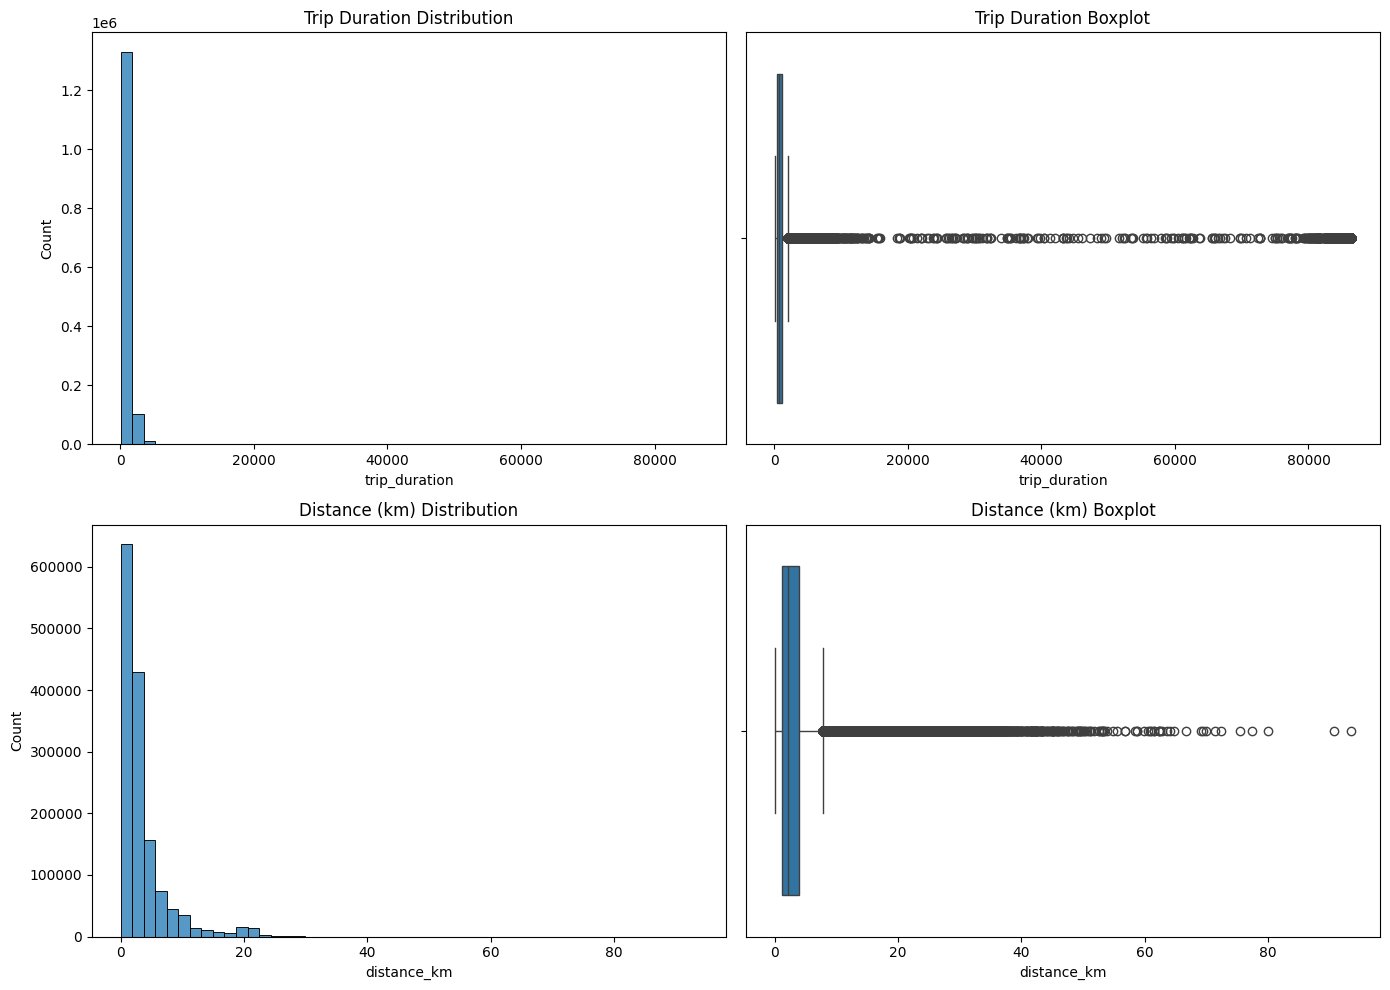

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['trip_duration'], bins=50, ax=axes[0,0])
axes[0,0].set_title('Trip Duration Distribution')

sns.boxplot(x=df['trip_duration'], ax=axes[0,1])
axes[0,1].set_title('Trip Duration Boxplot')

sns.histplot(df['distance_km'], bins=50, ax=axes[1,0])
axes[1,0].set_title('Distance (km) Distribution')

sns.boxplot(x=df['distance_km'], ax=axes[1,1])
axes[1,1].set_title('Distance (km) Boxplot')

plt.tight_layout()
plt.show()

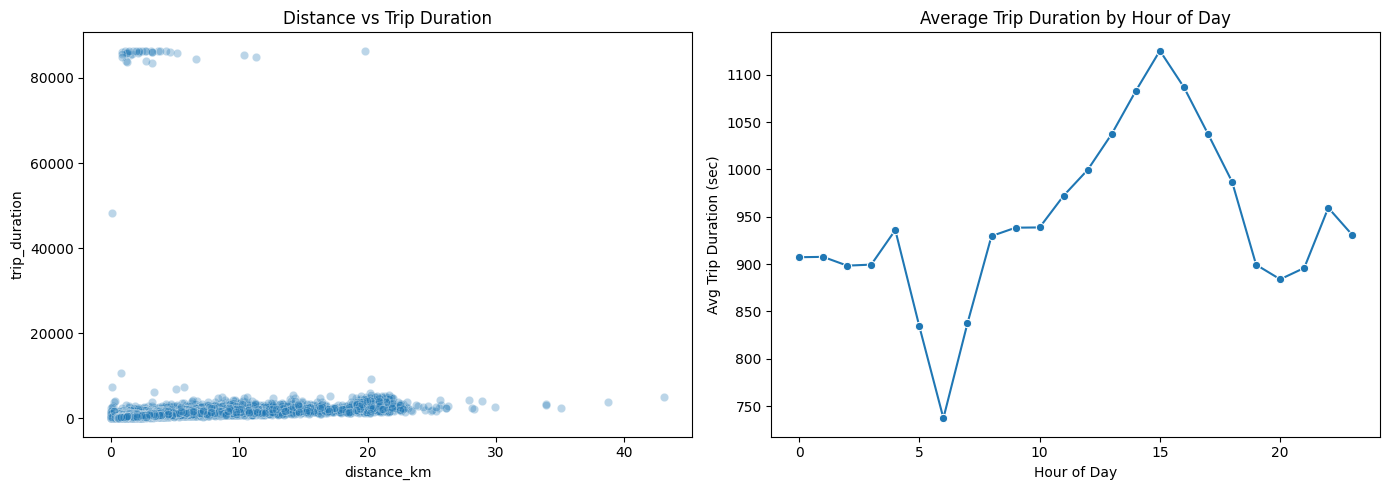

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance vs Duration
sample = df.sample(20000, random_state=42)
sns.scatterplot(x='distance_km', y='trip_duration', data=sample, alpha=0.3, ax=axes[0])
axes[0].set_title('Distance vs Trip Duration')

# Average duration by hour of day
hourly_avg = df.groupby('hour_of_day')['trip_duration'].mean()
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, ax=axes[1], marker='o')
axes[1].set_title('Average Trip Duration by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg Trip Duration (sec)')

plt.tight_layout()
plt.show()

In [ ]:
print("Before:", df.shape)
df = df[df['trip_duration'] <= 7200]
print("After:", df.shape)

Before: (1445757, 15)
After: (1443517, 15)


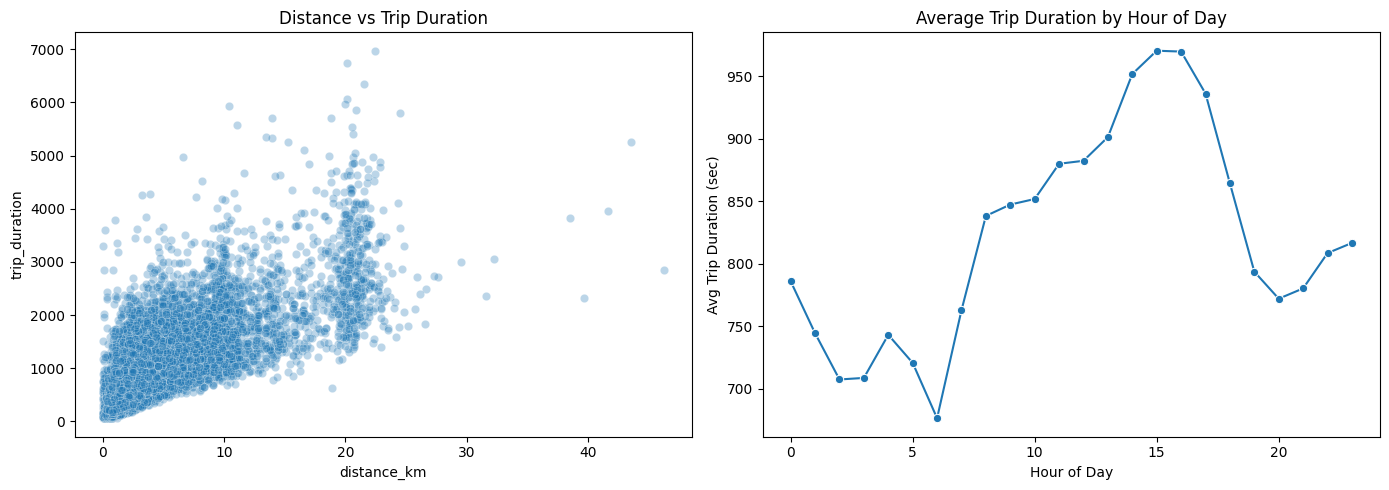

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance vs Duration
sample = df.sample(20000, random_state=42)
sns.scatterplot(x='distance_km', y='trip_duration', data=sample, alpha=0.3, ax=axes[0])
axes[0].set_title('Distance vs Trip Duration')

# Average duration by hour of day
hourly_avg = df.groupby('hour_of_day')['trip_duration'].mean()
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, ax=axes[1], marker='o')
axes[1].set_title('Average Trip Duration by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg Trip Duration (sec)')

plt.tight_layout()
plt.show()

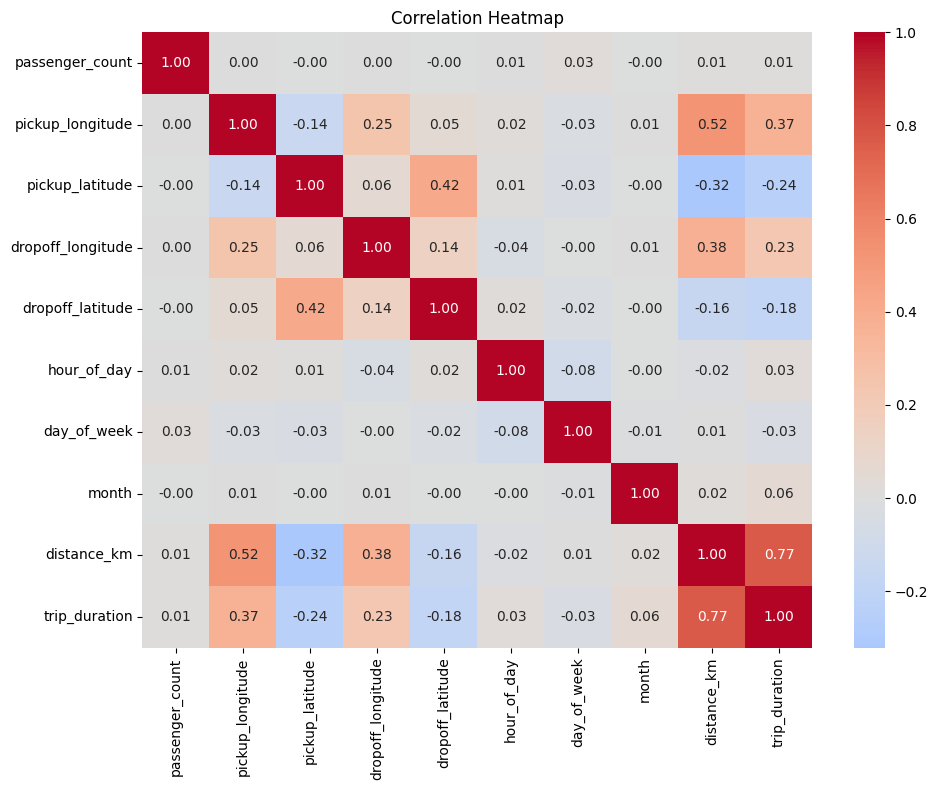

In [ ]:
plt.figure(figsize=(10, 8))
corr_cols = ['passenger_count', 'pickup_longitude', 'pickup_latitude',
             'dropoff_longitude', 'dropoff_latitude', 'hour_of_day',
             'day_of_week', 'month', 'distance_km', 'trip_duration']

corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()